# OMI Transactions Exploration

Exploratory analysis of OMI normalized transaction volumes (NTN) for Italian municipalities, 2011–2025.

**Workflow:** ingestion → schema harmonization → key validation → controlled joins → residential reconciliation → national/regional trends → size mix → municipality panel → analytical hand-off to price/volume analysis.


## 1. Setup

The loader discovers annual releases instead of hard-coding years. Each release contains `LISTA-COM`, `VALORI-RES`, `VALORI-COM` and `VALORI-PER`.


In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
TRANSACTIONS_FOLDER = PROJECT_ROOT / 'data' / 'raw' / 'transactions'
YEAR_FOLDERS = sorted(p for p in TRANSACTIONS_FOLDER.iterdir() if p.is_dir() and p.name.isdigit())
YEARS = [int(p.name) for p in YEAR_FOLDERS]
print(f'Releases: {min(YEARS)}–{max(YEARS)} ({len(YEARS)} years)')

Releases: 2011–2025 (15 years)


## 2. Load and harmonize annual releases

OMI uses semicolon-separated files and comma decimals. Year-specific field names are normalized so the analysis is independent of the release year.


In [11]:
def get_files(folder):
    files = {f.name.lower(): f for f in folder.iterdir() if f.is_file()}
    patterns = {'lista_com':'lista-com','valori_res':'valori-res','valori_com':'valori-com','valori_per':'valori-per'}
    out = {}
    for key, pattern in patterns.items():
        matches = [f for name, f in files.items() if pattern in name]
        if len(matches) != 1:
            raise ValueError(f'{folder.name}: expected one {pattern} file, found {len(matches)}')
        out[key] = matches[0]
    return out

def load_source(path, year):
    df = pd.read_csv(path, sep=';', decimal=',')
    df.columns = [str(c).strip() for c in df.columns]
    codcom = next((c for c in df.columns if re.search(r'codcom$', c, re.I)), None)
    if codcom is None:
        raise KeyError(f'{path.name}: CodCom column not found')
    df = df.rename(columns={codcom: 'CodCom'})
    df.columns = [re.sub(str(year), 'YEAR', c, flags=re.I) for c in df.columns]
    return df

sources = {k:{} for k in ['lista_com','valori_res','valori_com','valori_per']}
inventory = []
for folder in YEAR_FOLDERS:
    year = int(folder.name)
    files = get_files(folder)
    inventory.append({'year':year, **{k:v.name for k,v in files.items()}})
    for key, path in files.items():
        sources[key][year] = load_source(path, year)

inventory_df = pd.DataFrame(inventory)
inventory_df

,year,lista_com,valori_res,valori_com,valori_per
0,2011,2011_LISTA-COM.csv,2011_VALORI-RES.csv,2011_VALORI-COM.csv,2011_VALORI-PER.csv
1,2012,2012_LISTA-COM.csv,2012_VALORI-RES.csv,2012_VALORI-COM.csv,2012_VALORI-PER.csv
2,2013,2013_LISTA-COM.csv,2013_VALORI-RES.csv,2013_VALORI-COM.csv,2013_VALORI-PER.csv
3,2014,2014_LISTA-COM.csv,2014_VALORI-RES.csv,2014_VALORI-COM.csv,2014_VALORI-PER.csv
4,2015,2015_LISTA-COM.csv,2015_VALORI-RES.csv,2015_VALORI-COM.csv,2015_VALORI-PER.csv
5,2016,2016_LISTA-COM.csv,2016_VALORI-RES.csv,2016_VALORI-COM.csv,2016_VALORI-PER.csv
6,2017,2017_LISTA-COM.csv,2017_VALORI-RES.csv,2017_VALORI-COM.csv,2017_VALORI-PER.csv
7,2018,2018_LISTA-COM.csv,2018_VALORI-RES.csv,2018_VALORI-COM.csv,2018_VALORI-PER.csv
8,2019,2019_LISTA-COM.csv,2019_VALORI-RES.csv,2019_VALORI-COM.csv,2019_VALORI-PER.csv
9,2020,2020_LISTA-COM.csv,2020_VALORI-RES.csv,2020_VALORI-COM.csv,2020_VALORI-PER.csv


## 3. Validate keys before joining

`CodCom` is the municipality key. A duplicate key would make a later merge potentially many-to-many and inflate transaction volumes. The join is therefore deliberately protected with `validate='one_to_one'`.


In [12]:
def key_report(dataset):
    rows=[]
    for year, df in sources[dataset].items():
        rows.append({'dataset':dataset,'year':year,'rows':len(df),'unique_codcom':df.CodCom.nunique(),'missing_codcom':df.CodCom.isna().sum(),'duplicate_codcom':df.CodCom.duplicated().sum()})
    return pd.DataFrame(rows)

quality = pd.concat([key_report(k) for k in sources], ignore_index=True)
quality.sort_values(['dataset','year'])

assert quality.loc[quality.dataset.eq('lista_com'),'duplicate_codcom'].eq(0).all()


## 4. Build the municipality-year analytical spine

`LISTA-COM` supplies the geographic spine. Transaction measures are added with left joins, preserving municipalities listed by OMI even when a category is missing.


In [15]:
def prepare_year(year):
    base = sources['lista_com'][year].copy()

    geography = [
        c for c in [
            'Area',
            'Regione',
            'Provincia',
            'CodCom',
            'Comune',
            'Cap',
            'TAGLIA MERCATO'
        ]
        if c in base.columns
    ]

    base = base[geography]

    for dataset in ['valori_res', 'valori_com', 'valori_per']:
        src = sources[dataset][year].copy()

        # Remove rows without a valid municipality code.
        # OMI source files may contain special rows such as
        # "non nato" / "non nati", which are not municipality records.
        invalid_codcom = (
            src['CodCom']
            .astype('string')
            .str.strip()
            .str.lower()
            .isin({'non nato', 'non nati'})
        )

        if invalid_codcom.any():
            print(
                f'⚠️ {dataset} - {year}: '
                f'removing {invalid_codcom.sum():,} rows '
                f'with invalid CodCom values'
            )

            src = src.loc[~invalid_codcom].copy()

        # Verify that CodCom is unique after removing invalid rows.
        duplicate_codcom = src[
            src['CodCom'].duplicated(keep=False)
        ]

        if not duplicate_codcom.empty:
            print(
                f'⚠️ Duplicate CodCom still found in '
                f'{dataset} - {year}:'
            )
            print(
                duplicate_codcom['CodCom']
                .value_counts()
                .head(20)
            )

            raise ValueError(
                f'CodCom is not unique in {dataset} for {year}'
            )

        base = base.merge(
            src,
            on='CodCom',
            how='left',
            validate='one_to_one',
            suffixes=('', f'_{dataset}')
        )

    base['year'] = year

    return base


transactions_full = pd.concat(
    [prepare_year(y) for y in YEARS],
    ignore_index=True
)

assert not transactions_full.duplicated(
    ['year', 'CodCom']
).any()

# Explicit numeric conversion:
# zero remains zero; invalid text becomes missing.
id_cols = {
    'Area',
    'Regione',
    'Provincia',
    'CodCom',
    'Comune',
    'Cap',
    'TAGLIA MERCATO',
    'year'
}

for col in [
    c for c in transactions_full.columns
    if c not in id_cols
]:
    transactions_full[col] = pd.to_numeric(
        transactions_full[col],
        errors='coerce'
    )

print(f'Rows: {len(transactions_full):,}')
print(
    'Municipality-years: '
    f'{transactions_full[["year", "CodCom"]].drop_duplicates().shape[0]:,}'
)

⚠️ valori_res - 2017: removing 15 rows with invalid CodCom values
Rows: 114,262
Municipality-years: 114,262


## 5. Residential NTN integrity check

The residential file contains total NTN plus five size classes. The size classes should reconcile to total NTN apart from rounding. We **flag** discrepancies rather than silently correcting them.


In [16]:
size_cols = [c for c in transactions_full.columns if re.search(r'NTN YEAR .*mq', c, re.I)]
total_ntn_col = 'NTN_YEAR' if 'NTN_YEAR' in transactions_full.columns else next((c for c in transactions_full.columns if re.fullmatch(r'NTN_YEAR', c, re.I)), None)
print('Size classes:', size_cols)
print('Total NTN:', total_ntn_col)

if len(size_cols) == 5 and total_ntn_col:
    transactions_full['ntn_size_sum'] = transactions_full[size_cols].sum(axis=1, min_count=1)
    transactions_full['ntn_reconciliation_diff'] = transactions_full['ntn_size_sum'] - transactions_full[total_ntn_col]
    transactions_full['ntn_reconciles'] = transactions_full['ntn_reconciliation_diff'].abs().le(0.05)
    reconciliation = transactions_full['ntn_reconciles'].value_counts(dropna=False).rename_axis('reconciles').to_frame('rows')
    reconciliation['share_pct'] = reconciliation['rows'] / len(transactions_full) * 100
    reconciliation
else:
    print('Schema warning: size-band reconciliation not available.')

Size classes: ['NTN YEAR fino a 50 mq', 'NTN YEAR  50 -| 85 mq', 'NTN YEAR  85 -| 115 mq', 'NTN YEAR 115 -| 145 mq', 'NTN YEAR oltre 145 mq', 'NTN YEAR 50 -| 85 mq', 'NTN YEAR 85 -| 115 mq', 'NTN YEAR  oltre 145 mq', 'NTN YEAR fino a 50_mq']
Total NTN: NTN_YEAR
Schema warning: size-band reconciliation not available.


In [23]:
print('NTN-related columns:')
for col in transactions_full.columns:
    if 'NTN' in str(col).upper():
        print(repr(col))

print('\nDtypes:')
for col in transactions_full.columns:
    if 'NTN' in str(col).upper():
        print(f'{col!r}: {transactions_full[col].dtype}')

print('\nNon-null values by year:')
for col in transactions_full.columns:
    if 'NTN' in str(col).upper():
        print(f'\n{col}')
        print(
            transactions_full
            .groupby('year')[col]
            .count()
        )

NTN-related columns:
'NTN YEAR fino a 50 mq'
'NTN YEAR  50 -| 85 mq'
'NTN YEAR  85 -| 115 mq'
'NTN YEAR 115 -| 145 mq'
'NTN YEAR oltre 145 mq'
'NTN YEAR'
'NTN_YEAR_Uffici'
'NTN_YEAR_Negozi_Lab'
'NTN_YEAR_Depositi_Comm'
'NTN_YEAR_TCO_B04'
'NTN_YEAR_TCO_D02'
'NTN_YEAR_TCO_D05'
'NTN_YEAR_TCO_D08'
'NTN_YEAR_PRO'
'NTN_YEAR_AGR'
'NTN_YEAR_Box'
'NTN_YEAR_Depositi_Pert'
'NTN YEAR 50 -| 85 mq'
'NTN YEAR 85 -| 115 mq'
'NTN YEAR  oltre 145 mq'
'NTN YEAR oltre 145'
'NTN YEAR_TOTALE'
'NTN YEAR fino a 50_mq'
'NTN  YEAR 50 -| 85 mq'
'NTN  YEAR 85 -| 115 mq'
'NTN  YEAR 115 -| 145 mq'
'NTN   YEAR oltre 145 mq'
'NTN_YEAR_Depositi_Comm_Autorimesse'
'NTN fino a 50 mq'
'NTN 50 -| 85 mq'
'NTN  85 -| 115 mq'
'NTN 115 -| 145 mq'
'NTN  oltre 145 mq'
'NTN  YEAR oltre 145 mq'
'NTN_YEAR'

Dtypes:
'NTN YEAR fino a 50 mq': float64
'NTN YEAR  50 -| 85 mq': float64
'NTN YEAR  85 -| 115 mq': float64
'NTN YEAR 115 -| 145 mq': float64
'NTN YEAR oltre 145 mq': float64
'NTN YEAR': float64
'NTN_YEAR_Uffici': float64
'NTN_Y

In [24]:
ntn_cols = [
    c for c in transactions_full.columns
    if 'NTN' in str(c).upper()
]

ntn_coverage = []

for year, group in transactions_full.groupby('year'):

    for col in ntn_cols:
        non_null = group[col].notna().sum()

        if non_null > 0:
            ntn_coverage.append({
                'year': year,
                'column': col,
                'non_null': non_null,
            })

ntn_coverage = pd.DataFrame(ntn_coverage)

display(ntn_coverage)

,year,column,non_null
0,2011,NTN YEAR fino a 50 mq,7715
1,2011,NTN YEAR 50 -| 85 mq,7715
2,2011,NTN YEAR 85 -| 115 mq,7715
3,2011,NTN YEAR 115 -| 145 mq,7715
4,2011,NTN YEAR oltre 145 mq,7715
...,...,...,...
250,2025,NTN_YEAR_Depositi_Pert,7560
251,2025,NTN YEAR 50 -| 85 mq,7560
252,2025,NTN YEAR 85 -| 115 mq,7560
253,2025,NTN_YEAR_Depositi_Comm_Autorimesse,7560


In [25]:
# ============================================================
# ANALISI DELLE COLONNE NTN TOTALI
# ============================================================

candidate_total_cols = [
    c for c in transactions_full.columns
    if re.fullmatch(
        r'NTN[\s]*YEAR(?:_TOTALE)?',
        str(c),
        re.IGNORECASE
    )
]

print("Candidate total NTN columns:")
for col in candidate_total_cols:
    print(f"  - {col}")

print("\nCoverage by year:")

total_coverage = []

for year, group in transactions_full.groupby('year'):

    for col in candidate_total_cols:
        non_null = group[col].notna().sum()

        if non_null > 0:
            total_coverage.append({
                'year': year,
                'column': col,
                'non_null': non_null
            })

total_coverage = pd.DataFrame(total_coverage)

display(total_coverage)

Candidate total NTN columns:
  - NTN YEAR
  - NTN YEAR_TOTALE

Coverage by year:


,year,column,non_null
0,2011,NTN YEAR,7715
1,2012,NTN YEAR,7715
2,2013,NTN YEAR,7698
3,2014,NTN YEAR,7665
4,2015,NTN YEAR_TOTALE,7661
5,2016,NTN YEAR_TOTALE,7645
6,2017,NTN YEAR,7624
7,2018,NTN YEAR,7603
8,2019,NTN YEAR,7564
9,2020,NTN YEAR,7562


In [26]:
# ============================================================
# CANONICAL NATIONAL TRANSACTIONS NUMBER (NTN)
# ============================================================

transactions_full['ntn_total'] = np.nan

# Historical schema mapping
ntn_column_by_year = {
    2011: 'NTN YEAR',
    2012: 'NTN YEAR',
    2013: 'NTN YEAR',
    2014: 'NTN YEAR',
    2015: 'NTN YEAR_TOTALE',
    2016: 'NTN YEAR_TOTALE',
    2017: 'NTN YEAR',
    2018: 'NTN YEAR',
    2019: 'NTN YEAR',
    2020: 'NTN YEAR',
    2021: 'NTN YEAR',
    2022: 'NTN_YEAR',
    2023: 'NTN_YEAR',
    2024: 'NTN_YEAR',
    2025: 'NTN_YEAR',
}

for year, source_col in ntn_column_by_year.items():

    mask = transactions_full['year'].eq(year)

    transactions_full.loc[mask, 'ntn_total'] = (
        transactions_full.loc[mask, source_col]
    )

# Check coverage
ntn_coverage = (
    transactions_full
    .groupby('year')
    .agg(
        municipalities=('CodCom', 'nunique'),
        ntn_non_null=('ntn_total', 'count'),
        ntn_sum=('ntn_total', 'sum')
    )
    .reset_index()
)

ntn_coverage['coverage_pct'] = (
    ntn_coverage['ntn_non_null']
    / ntn_coverage['municipalities']
    * 100
)

display(ntn_coverage)

,year,municipalities,ntn_non_null,ntn_sum,coverage_pct
0,2011,7715,7715,575797.10,100.0
1,2012,7715,7715,427566.36,100.0
2,2013,7698,7698,389447.90,100.0
3,2014,7665,7665,405721.52,100.0
4,2015,7661,7661,435931.25,100.0
5,2016,7645,7645,517184.41,100.0
6,2017,7624,7624,543187.68,100.0
7,2018,7603,7603,579207.17,100.0
8,2019,7564,7564,604167.77,100.0
9,2020,7562,7562,558721.59,100.0


In [27]:
# ============================================================
# NATIONAL NTN TIME SERIES
# ============================================================

national_ntn = (
    transactions_full
    .groupby('year', as_index=False)
    .agg(
        national_ntn=('ntn_total', 'sum')
    )
)

national_ntn['yoy_pct'] = (
    national_ntn['national_ntn']
    .pct_change() * 100
)

display(national_ntn)

,year,national_ntn,yoy_pct
0,2011,575797.10,NaN
1,2012,427566.36,-25.743572
2,2013,389447.90,-8.915215
3,2014,405721.52,4.178639
4,2015,435931.25,7.445927
5,2016,517184.41,18.638985
6,2017,543187.68,5.027853
7,2018,579207.17,6.631132
8,2019,604167.77,4.309443
9,2020,558721.59,-7.522113


In [28]:
# ============================================================
# VALIDATION
# ============================================================

validation = (
    transactions_full
    .groupby('year')
    .agg(
        rows=('CodCom', 'size'),
        municipalities=('CodCom', 'nunique'),
        ntn_non_null=('ntn_total', 'count'),
        ntn_zero=('ntn_total', lambda x: (x == 0).sum()),
        ntn_sum=('ntn_total', 'sum')
    )
    .reset_index()
)

validation['missing_ntn'] = (
    validation['municipalities']
    - validation['ntn_non_null']
)

display(validation)

,year,rows,municipalities,ntn_non_null,ntn_zero,ntn_sum,missing_ntn
0,2011,7715,7715,7715,107,575797.10,0
1,2012,7715,7715,7715,165,427566.36,0
2,2013,7698,7698,7698,176,389447.90,0
3,2014,7665,7665,7665,193,405721.52,0
4,2015,7661,7661,7661,174,435931.25,0
5,2016,7645,7645,7645,153,517184.41,0
6,2017,7624,7624,7624,144,543187.68,0
7,2018,7603,7603,7603,128,579207.17,0
8,2019,7564,7564,7564,109,604167.77,0
9,2020,7562,7562,7562,141,558721.59,0


In [29]:
# ============================================================
# NORMALIZZAZIONE FASCE NTN RESIDENZIALI
# ============================================================

import re
import numpy as np

# ------------------------------------------------------------
# Funzione di normalizzazione del nome della colonna
# ------------------------------------------------------------

def normalize_ntn_column_name(column):
    """
    Normalizza il nome di una colonna NTN per facilitare
    il riconoscimento delle fasce dimensionali.
    """
    name = str(column).lower().strip()

    # Uniforma gli spazi
    name = re.sub(r'\s+', ' ', name)

    # Uniforma separatori e caratteri
    name = name.replace('_', ' ')
    name = name.replace('|', '')
    
    return name


# ------------------------------------------------------------
# Classificazione delle colonne NTN per fascia
# ------------------------------------------------------------

def classify_ntn_size_column(column):
    """
    Restituisce la fascia NTN associata alla colonna.
    Restituisce None se la colonna non rappresenta una
    fascia dimensionale residenziale.
    """

    name = normalize_ntn_column_name(column)

    # Deve essere una colonna NTN
    if 'ntn' not in name:
        return None

    # Deve essere riferita alla superficie
    if 'mq' not in name:
        return None

    # 0-50 mq
    if re.search(r'fino a 50', name):
        return 'ntn_0_50'

    # 50-85 mq
    if re.search(r'50\s*-\s*85', name):
        return 'ntn_50_85'

    # 85-115 mq
    if re.search(r'85\s*-\s*115', name):
        return 'ntn_85_115'

    # 115-145 mq
    if re.search(r'115\s*-\s*145', name):
        return 'ntn_115_145'

    # oltre 145 mq
    if re.search(r'oltre\s*145', name):
        return 'ntn_over_145'

    return None

In [30]:
# ============================================================
# MAPPATURA COLONNE NTN -> FASCE CANONICHE
# ============================================================

ntn_size_mapping = []

for column in transactions_full.columns:

    size_class = classify_ntn_size_column(column)

    if size_class is not None:
        ntn_size_mapping.append({
            'original_column': column,
            'canonical_column': size_class
        })

ntn_size_mapping = pd.DataFrame(ntn_size_mapping)

display(ntn_size_mapping)

,original_column,canonical_column
0,NTN YEAR fino a 50 mq,ntn_0_50
1,NTN YEAR 50 -| 85 mq,ntn_50_85
2,NTN YEAR 85 -| 115 mq,ntn_85_115
3,NTN YEAR 115 -| 145 mq,ntn_115_145
4,NTN YEAR oltre 145 mq,ntn_over_145
5,NTN YEAR 50 -| 85 mq,ntn_50_85
6,NTN YEAR 85 -| 115 mq,ntn_85_115
7,NTN YEAR oltre 145 mq,ntn_over_145
8,NTN YEAR fino a 50_mq,ntn_0_50
9,NTN YEAR 50 -| 85 mq,ntn_50_85


In [31]:
# ============================================================
# COLONNE NTN PER ANNO
# ============================================================

year_size_columns = {}

for year in sorted(transactions_full['year'].unique()):

    subset = transactions_full.loc[
        transactions_full['year'] == year
    ]

    available = {}

    for column in transactions_full.columns:

        canonical = classify_ntn_size_column(column)

        if canonical is None:
            continue

        non_null = subset[column].notna().sum()

        if non_null > 0:
            available.setdefault(canonical, []).append({
                'column': column,
                'non_null': non_null
            })

    year_size_columns[year] = available


# Visualizzazione
for year, mapping in year_size_columns.items():

    print(f"\n{'=' * 60}")
    print(f"YEAR {year}")
    print(f"{'=' * 60}")

    for canonical, candidates in mapping.items():

        print(f"\n{canonical}")

        for candidate in candidates:
            print(
                f"  {candidate['column']} "
                f"→ {candidate['non_null']:,} non-null"
            )


YEAR 2011

ntn_0_50
  NTN YEAR fino a 50 mq → 7,715 non-null

ntn_50_85
  NTN YEAR  50 -| 85 mq → 7,715 non-null

ntn_85_115
  NTN YEAR  85 -| 115 mq → 7,715 non-null

ntn_115_145
  NTN YEAR 115 -| 145 mq → 7,715 non-null

ntn_over_145
  NTN YEAR oltre 145 mq → 7,715 non-null

YEAR 2012

ntn_0_50
  NTN YEAR fino a 50 mq → 7,715 non-null

ntn_115_145
  NTN YEAR 115 -| 145 mq → 7,715 non-null

ntn_50_85
  NTN YEAR 50 -| 85 mq → 7,715 non-null

ntn_85_115
  NTN YEAR 85 -| 115 mq → 7,715 non-null

ntn_over_145
  NTN YEAR  oltre 145 mq → 7,715 non-null

YEAR 2013

ntn_0_50
  NTN YEAR fino a 50 mq → 7,698 non-null

ntn_115_145
  NTN YEAR 115 -| 145 mq → 7,698 non-null

ntn_over_145
  NTN YEAR oltre 145 mq → 7,698 non-null

ntn_50_85
  NTN YEAR 50 -| 85 mq → 7,698 non-null

ntn_85_115
  NTN YEAR 85 -| 115 mq → 7,698 non-null

YEAR 2014

ntn_0_50
  NTN YEAR fino a 50 mq → 7,665 non-null

ntn_115_145
  NTN YEAR 115 -| 145 mq → 7,665 non-null

ntn_50_85
  NTN YEAR 50 -| 85 mq → 7,665 non-null



In [32]:
# ============================================================
# CREAZIONE COLONNE NTN CANONICHE
# ============================================================

canonical_size_columns = [
    'ntn_0_50',
    'ntn_50_85',
    'ntn_85_115',
    'ntn_115_145',
    'ntn_over_145'
]

for column in canonical_size_columns:
    transactions_full[column] = np.nan


for year in sorted(transactions_full['year'].unique()):

    year_mask = transactions_full['year'].eq(year)

    for canonical in canonical_size_columns:

        candidates = year_size_columns.get(year, {}).get(
            canonical,
            []
        )

        if not candidates:
            continue

        # Prendiamo la colonna con maggiore copertura
        best_candidate = max(
            candidates,
            key=lambda x: x['non_null']
        )

        source_column = best_candidate['column']

        transactions_full.loc[
            year_mask,
            canonical
        ] = transactions_full.loc[
            year_mask,
            source_column
        ]

        print(
            f"{year} | "
            f"{canonical:<15} | "
            f"{source_column}"
        )

2011 | ntn_0_50        | NTN YEAR fino a 50 mq
2011 | ntn_50_85       | NTN YEAR  50 -| 85 mq
2011 | ntn_85_115      | NTN YEAR  85 -| 115 mq
2011 | ntn_115_145     | NTN YEAR 115 -| 145 mq
2011 | ntn_over_145    | NTN YEAR oltre 145 mq
2012 | ntn_0_50        | NTN YEAR fino a 50 mq
2012 | ntn_50_85       | NTN YEAR 50 -| 85 mq
2012 | ntn_85_115      | NTN YEAR 85 -| 115 mq
2012 | ntn_115_145     | NTN YEAR 115 -| 145 mq
2012 | ntn_over_145    | NTN YEAR  oltre 145 mq
2013 | ntn_0_50        | NTN YEAR fino a 50 mq
2013 | ntn_50_85       | NTN YEAR 50 -| 85 mq
2013 | ntn_85_115      | NTN YEAR 85 -| 115 mq
2013 | ntn_115_145     | NTN YEAR 115 -| 145 mq
2013 | ntn_over_145    | NTN YEAR oltre 145 mq
2014 | ntn_0_50        | NTN YEAR fino a 50 mq
2014 | ntn_50_85       | NTN YEAR 50 -| 85 mq
2014 | ntn_85_115      | NTN YEAR 85 -| 115 mq
2014 | ntn_115_145     | NTN YEAR 115 -| 145 mq
2015 | ntn_0_50        | NTN YEAR fino a 50 mq
2015 | ntn_50_85       | NTN YEAR 50 -| 85 mq
2015 | ntn_

In [33]:
# ============================================================
# RICONCILIAZIONE NTN PER FASCE DIMENSIONALI
# ============================================================

size_columns = [
    'ntn_0_50',
    'ntn_50_85',
    'ntn_85_115',
    'ntn_115_145',
    'ntn_over_145'
]

transactions_full['ntn_size_sum'] = (
    transactions_full[size_columns]
    .sum(axis=1, min_count=1)
)

transactions_full['ntn_reconciliation_diff'] = (
    transactions_full['ntn_size_sum']
    - transactions_full['ntn_total']
)

transactions_full['ntn_reconciles'] = (
    transactions_full['ntn_reconciliation_diff']
    .abs()
    .le(0.05)
)

In [34]:
# ============================================================
# REPORT ANNUALE RICONCILIAZIONE
# ============================================================

reconciliation_by_year = (
    transactions_full
    .groupby('year')
    .agg(
        municipalities=('CodCom', 'nunique'),

        ntn_total=('ntn_total', 'sum'),

        ntn_0_50=('ntn_0_50', 'sum'),
        ntn_50_85=('ntn_50_85', 'sum'),
        ntn_85_115=('ntn_85_115', 'sum'),
        ntn_115_145=('ntn_115_145', 'sum'),
        ntn_over_145=('ntn_over_145', 'sum'),

        reconciled_rows=('ntn_reconciles', 'sum'),
        total_rows=('ntn_reconciles', 'count')
    )
    .reset_index()
)

reconciliation_by_year['size_sum'] = (
    reconciliation_by_year[
        size_columns
    ].sum(axis=1, min_count=1)
)

reconciliation_by_year['difference'] = (
    reconciliation_by_year['size_sum']
    - reconciliation_by_year['ntn_total']
)

reconciliation_by_year['reconciliation_pct'] = (
    reconciliation_by_year['reconciled_rows']
    / reconciliation_by_year['total_rows']
    * 100
)

display(reconciliation_by_year)

,year,municipalities,ntn_total,ntn_0_50,ntn_50_85,ntn_85_115,ntn_115_145,ntn_over_145,reconciled_rows,total_rows,size_sum,difference,reconciliation_pct
0,2011,7715,575797.10,57745.96,193908.88,154469.25,88970.04,80702.97,7715,7715,575797.10,0.000000e+00,100.000000
1,2012,7715,427566.36,42901.05,141187.52,115449.02,66455.19,61573.58,7715,7715,427566.36,5.820766e-11,100.000000
2,2013,7698,389447.90,38626.01,126872.18,104847.42,61558.52,57543.77,7698,7698,389447.90,0.000000e+00,100.000000
3,2014,7665,405721.52,36142.99,127554.23,109927.36,69807.43,0.00,1223,7665,343432.01,-6.228951e+04,15.955643
4,2015,7661,435931.25,38154.19,134233.13,119373.69,74850.90,69319.34,7661,7661,435931.25,0.000000e+00,100.000000
5,2016,7645,517184.41,46118.69,161020.79,141798.95,83591.45,84654.53,7645,7645,517184.41,5.820766e-11,100.000000
6,2017,7624,543187.68,48643.27,168731.27,148911.71,86954.12,89947.31,7624,7624,543187.68,-1.164153e-10,100.000000
7,2018,7603,579207.17,52325.24,178457.95,158863.39,92965.64,96594.95,7603,7603,579207.17,-1.164153e-10,100.000000
8,2019,7564,604167.77,55429.89,185651.59,164399.41,96480.18,102206.70,7564,7564,604167.77,0.000000e+00,100.000000
9,2020,7562,558721.59,50065.93,170017.91,149733.65,89502.99,99401.11,7562,7562,558721.59,0.000000e+00,100.000000


In [35]:
# ============================================================
# DEBUG NTN 2014
# ============================================================

ntn_2014 = transactions_full.loc[
    transactions_full['year'].eq(2014),
    [
        'CodCom',
        'Comune',
        'ntn_total',
        'ntn_0_50',
        'ntn_50_85',
        'ntn_85_115',
        'ntn_115_145',
        'ntn_over_145',
        'ntn_size_sum',
        'ntn_reconciliation_diff',
        'ntn_reconciles'
    ]
].copy()

# Ordiniamo per differenza assoluta
ntn_2014['abs_difference'] = (
    ntn_2014['ntn_reconciliation_diff'].abs()
)

display(
    ntn_2014
    .sort_values('abs_difference', ascending=False)
    .head(30)
)

,CodCom,Comune,ntn_total,ntn_0_50,ntn_50_85,ntn_85_115,ntn_115_145,ntn_over_145,ntn_size_sum,ntn_reconciliation_diff,ntn_reconciles,abs_difference
28760,H501,ROMA,27104.24,2196.21,11355.76,7473.42,3621.42,NaN,24646.81,-2457.43,False,2457.43
27004,F205,MILANO,15866.13,2668.25,6643.67,3546.54,1615.32,NaN,14473.78,-1392.35,False,1392.35
30002,L219,TORINO,9057.33,1193.01,4144.72,2170.91,915.56,NaN,8424.20,-633.13,False,633.13
27492,F839,NAPOLI,5308.39,778.05,1554.33,1490.69,879.21,NaN,4702.28,-606.11,False,606.11
27830,G273,PALERMO,3812.95,379.55,844.88,1051.50,950.79,NaN,3226.72,-586.23,False,586.23
26096,D969,GENOVA,5335.64,338.78,1906.62,1753.59,867.43,NaN,4866.42,-469.22,False,469.22
25817,D612,FIRENZE,3766.31,408.34,1252.14,1047.45,592.56,NaN,3300.49,-465.82,False,465.82
27791,G224,PADOVA,1733.04,150.97,373.19,536.28,362.33,NaN,1422.77,-310.27,False,310.27
23855,A944,BOLOGNA,4288.01,501.80,1632.38,1332.62,518.51,NaN,3985.31,-302.70,False,302.70
30413,L781,VERONA,2257.70,105.39,638.87,798.76,413.40,NaN,1956.42,-301.28,False,301.28


In [36]:
# ============================================================
# DISTRIBUZIONE 2014
# ============================================================

size_cols = [
    'ntn_0_50',
    'ntn_50_85',
    'ntn_85_115',
    'ntn_115_145',
    'ntn_over_145'
]

zero_nan_2014 = pd.DataFrame({
    'non_null': transactions_full.loc[
        transactions_full['year'].eq(2014),
        size_cols
    ].notna().sum(),

    'zero': transactions_full.loc[
        transactions_full['year'].eq(2014),
        size_cols
    ].eq(0).sum(),

    'positive': transactions_full.loc[
        transactions_full['year'].eq(2014),
        size_cols
    ].gt(0).sum()
})

display(zero_nan_2014)

,non_null,zero,positive
ntn_0_50,7665,3140,4525
ntn_50_85,7665,1384,6281
ntn_85_115,7665,1404,6261
ntn_115_145,7665,1573,6092
ntn_over_145,0,0,0


In [37]:
def classify_ntn_size_column(column):
    """
    Classifica una colonna NTN residenziale per fascia dimensionale.

    Gestisce le diverse convenzioni utilizzate nei dataset storici OMI,
    inclusa la variante 'NTN YEAR oltre 145' senza 'mq'.
    """

    name = normalize_ntn_column_name(column)

    if 'ntn' not in name:
        return None

    # 0-50 mq
    if re.search(r'fino a\s*50', name):
        return 'ntn_0_50'

    # 50-85 mq
    if re.search(r'50\s*-\s*85', name):
        return 'ntn_50_85'

    # 85-115 mq
    if re.search(r'85\s*-\s*115', name):
        return 'ntn_85_115'

    # 115-145 mq
    if re.search(r'115\s*-\s*145', name):
        return 'ntn_115_145'

    # oltre 145 mq
    # Gestisce sia:
    #   NTN YEAR oltre 145 mq
    #   NTN YEAR oltre 145
    if re.search(r'oltre\s*145', name):
        return 'ntn_over_145'

    return None

In [38]:
# ============================================================
# RICOSTRUZIONE MAPPATURA FASCE NTN
# ============================================================

year_size_columns = {}

for year in sorted(transactions_full['year'].unique()):

    subset = transactions_full.loc[
        transactions_full['year'] == year
    ]

    available = {}

    for column in transactions_full.columns:

        canonical = classify_ntn_size_column(column)

        if canonical is None:
            continue

        non_null = subset[column].notna().sum()

        if non_null > 0:
            available.setdefault(canonical, []).append({
                'column': column,
                'non_null': non_null
            })

    year_size_columns[year] = available


for year, mapping in year_size_columns.items():

    print(f"\n{'=' * 60}")
    print(f"YEAR {year}")
    print(f"{'=' * 60}")

    for canonical, candidates in mapping.items():

        for candidate in candidates:
            print(
                f"{canonical:<15} | "
                f"{candidate['column']} | "
                f"{candidate['non_null']:,}"
            )


YEAR 2011
ntn_0_50        | NTN YEAR fino a 50 mq | 7,715
ntn_50_85       | NTN YEAR  50 -| 85 mq | 7,715
ntn_85_115      | NTN YEAR  85 -| 115 mq | 7,715
ntn_115_145     | NTN YEAR 115 -| 145 mq | 7,715
ntn_over_145    | NTN YEAR oltre 145 mq | 7,715

YEAR 2012
ntn_0_50        | NTN YEAR fino a 50 mq | 7,715
ntn_115_145     | NTN YEAR 115 -| 145 mq | 7,715
ntn_50_85       | NTN YEAR 50 -| 85 mq | 7,715
ntn_85_115      | NTN YEAR 85 -| 115 mq | 7,715
ntn_over_145    | NTN YEAR  oltre 145 mq | 7,715

YEAR 2013
ntn_0_50        | NTN YEAR fino a 50 mq | 7,698
ntn_115_145     | NTN YEAR 115 -| 145 mq | 7,698
ntn_over_145    | NTN YEAR oltre 145 mq | 7,698
ntn_50_85       | NTN YEAR 50 -| 85 mq | 7,698
ntn_85_115      | NTN YEAR 85 -| 115 mq | 7,698

YEAR 2014
ntn_0_50        | NTN YEAR fino a 50 mq | 7,665
ntn_115_145     | NTN YEAR 115 -| 145 mq | 7,665
ntn_50_85       | NTN YEAR 50 -| 85 mq | 7,665
ntn_85_115      | NTN YEAR 85 -| 115 mq | 7,665
ntn_over_145    | NTN YEAR oltre 145 | 7,

In [39]:
# ============================================================
# RICOSTRUZIONE COLONNE CANONICHE NTN
# ============================================================

canonical_size_columns = [
    'ntn_0_50',
    'ntn_50_85',
    'ntn_85_115',
    'ntn_115_145',
    'ntn_over_145'
]

for column in canonical_size_columns:
    transactions_full[column] = np.nan


for year in sorted(transactions_full['year'].unique()):

    year_mask = transactions_full['year'].eq(year)

    for canonical in canonical_size_columns:

        candidates = year_size_columns.get(year, {}).get(
            canonical,
            []
        )

        if not candidates:
            continue

        best_candidate = max(
            candidates,
            key=lambda x: x['non_null']
        )

        source_column = best_candidate['column']

        transactions_full.loc[
            year_mask,
            canonical
        ] = transactions_full.loc[
            year_mask,
            source_column
        ]

In [40]:
# ============================================================
# RICONCILIAZIONE NTN
# ============================================================

size_columns = [
    'ntn_0_50',
    'ntn_50_85',
    'ntn_85_115',
    'ntn_115_145',
    'ntn_over_145'
]

transactions_full['ntn_size_sum'] = (
    transactions_full[size_columns]
    .sum(axis=1, min_count=1)
)

transactions_full['ntn_reconciliation_diff'] = (
    transactions_full['ntn_size_sum']
    - transactions_full['ntn_total']
)

transactions_full['ntn_reconciles'] = (
    transactions_full['ntn_reconciliation_diff']
    .abs()
    .le(0.05)
)

In [41]:
# ============================================================
# REPORT FINALE RICONCILIAZIONE
# ============================================================

reconciliation_by_year = (
    transactions_full
    .groupby('year')
    .agg(
        municipalities=('CodCom', 'nunique'),
        ntn_total=('ntn_total', 'sum'),
        ntn_0_50=('ntn_0_50', 'sum'),
        ntn_50_85=('ntn_50_85', 'sum'),
        ntn_85_115=('ntn_85_115', 'sum'),
        ntn_115_145=('ntn_115_145', 'sum'),
        ntn_over_145=('ntn_over_145', 'sum'),
        reconciled_rows=('ntn_reconciles', 'sum'),
        total_rows=('ntn_reconciles', 'count')
    )
    .reset_index()
)

reconciliation_by_year['size_sum'] = (
    reconciliation_by_year[size_columns]
    .sum(axis=1, min_count=1)
)

reconciliation_by_year['difference'] = (
    reconciliation_by_year['size_sum']
    - reconciliation_by_year['ntn_total']
)

reconciliation_by_year['reconciliation_pct'] = (
    reconciliation_by_year['reconciled_rows']
    / reconciliation_by_year['total_rows']
    * 100
)

display(reconciliation_by_year)

,year,municipalities,ntn_total,ntn_0_50,ntn_50_85,ntn_85_115,ntn_115_145,ntn_over_145,reconciled_rows,total_rows,size_sum,difference,reconciliation_pct
0,2011,7715,575797.10,57745.96,193908.88,154469.25,88970.04,80702.97,7715,7715,575797.10,0.000000e+00,100.0
1,2012,7715,427566.36,42901.05,141187.52,115449.02,66455.19,61573.58,7715,7715,427566.36,5.820766e-11,100.0
2,2013,7698,389447.90,38626.01,126872.18,104847.42,61558.52,57543.77,7698,7698,389447.90,0.000000e+00,100.0
3,2014,7665,405721.52,36142.99,127554.23,109927.36,69807.43,62289.51,7665,7665,405721.52,0.000000e+00,100.0
4,2015,7661,435931.25,38154.19,134233.13,119373.69,74850.90,69319.34,7661,7661,435931.25,0.000000e+00,100.0
5,2016,7645,517184.41,46118.69,161020.79,141798.95,83591.45,84654.53,7645,7645,517184.41,5.820766e-11,100.0
6,2017,7624,543187.68,48643.27,168731.27,148911.71,86954.12,89947.31,7624,7624,543187.68,-1.164153e-10,100.0
7,2018,7603,579207.17,52325.24,178457.95,158863.39,92965.64,96594.95,7603,7603,579207.17,-1.164153e-10,100.0
8,2019,7564,604167.77,55429.89,185651.59,164399.41,96480.18,102206.70,7564,7564,604167.77,0.000000e+00,100.0
9,2020,7562,558721.59,50065.93,170017.91,149733.65,89502.99,99401.11,7562,7562,558721.59,0.000000e+00,100.0


In [42]:
size_columns = [
    'ntn_0_50',
    'ntn_50_85',
    'ntn_85_115',
    'ntn_115_145',
    'ntn_over_145'
]

national_ntn = (
    transactions_full
    .groupby('year', as_index=False)
    .agg(
        municipalities=('CodCom', 'nunique'),
        ntn_total=('ntn_total', 'sum'),
        ntn_0_50=('ntn_0_50', 'sum'),
        ntn_50_85=('ntn_50_85', 'sum'),
        ntn_85_115=('ntn_85_115', 'sum'),
        ntn_115_145=('ntn_115_145', 'sum'),
        ntn_over_145=('ntn_over_145', 'sum')
    )
)

national_ntn['yoy_pct'] = (
    national_ntn['ntn_total'].pct_change() * 100
)

display(national_ntn)

,year,municipalities,ntn_total,ntn_0_50,ntn_50_85,ntn_85_115,ntn_115_145,ntn_over_145,yoy_pct
0,2011,7715,575797.10,57745.96,193908.88,154469.25,88970.04,80702.97,NaN
1,2012,7715,427566.36,42901.05,141187.52,115449.02,66455.19,61573.58,-25.743572
2,2013,7698,389447.90,38626.01,126872.18,104847.42,61558.52,57543.77,-8.915215
3,2014,7665,405721.52,36142.99,127554.23,109927.36,69807.43,62289.51,4.178639
4,2015,7661,435931.25,38154.19,134233.13,119373.69,74850.90,69319.34,7.445927
5,2016,7645,517184.41,46118.69,161020.79,141798.95,83591.45,84654.53,18.638985
6,2017,7624,543187.68,48643.27,168731.27,148911.71,86954.12,89947.31,5.027853
7,2018,7603,579207.17,52325.24,178457.95,158863.39,92965.64,96594.95,6.631132
8,2019,7564,604167.77,55429.89,185651.59,164399.41,96480.18,102206.70,4.309443
9,2020,7562,558721.59,50065.93,170017.91,149733.65,89502.99,99401.11,-7.522113


In [43]:
for col in size_columns:
    national_ntn[f'{col}_share_pct'] = (
        national_ntn[col] / national_ntn['ntn_total'] * 100
    )

display(national_ntn)

,year,municipalities,ntn_total,ntn_0_50,ntn_50_85,ntn_85_115,ntn_115_145,ntn_over_145,yoy_pct,ntn_0_50_share_pct,ntn_50_85_share_pct,ntn_85_115_share_pct,ntn_115_145_share_pct,ntn_over_145_share_pct
0,2011,7715,575797.10,57745.96,193908.88,154469.25,88970.04,80702.97,NaN,10.028873,33.676599,26.827028,15.451630,14.015869
1,2012,7715,427566.36,42901.05,141187.52,115449.02,66455.19,61573.58,-25.743572,10.033776,33.021195,27.001427,15.542661,14.400941
2,2013,7698,389447.90,38626.01,126872.18,104847.42,61558.52,57543.77,-8.915215,9.918146,32.577446,26.922066,15.806612,14.775730
3,2014,7665,405721.52,36142.99,127554.23,109927.36,69807.43,62289.51,4.178639,8.908325,31.438862,27.094289,17.205750,15.352774
4,2015,7661,435931.25,38154.19,134233.13,119373.69,74850.90,69319.34,7.445927,8.752341,30.792271,27.383605,17.170345,15.901439
5,2016,7645,517184.41,46118.69,161020.79,141798.95,83591.45,84654.53,18.638985,8.917262,31.134115,27.417483,16.162794,16.368345
6,2017,7624,543187.68,48643.27,168731.27,148911.71,86954.12,89947.31,5.027853,8.955150,31.063162,27.414412,16.008117,16.559159
7,2018,7603,579207.17,52325.24,178457.95,158863.39,92965.64,96594.95,6.631132,9.033942,30.810729,27.427732,16.050499,16.677098
8,2019,7564,604167.77,55429.89,185651.59,164399.41,96480.18,102206.70,4.309443,9.174586,30.728483,27.210887,15.969104,16.916940
9,2020,7562,558721.59,50065.93,170017.91,149733.65,89502.99,99401.11,-7.522113,8.960801,30.429809,26.799331,16.019247,17.790812


## 6. Coverage and national market activity

For national activity, aggregate **sum of NTN**, not the mean across municipalities. This preserves the economic meaning of transaction volume.


In [17]:
coverage = transactions_full.groupby('year').agg(municipalities=('CodCom','nunique'), provinces=('Provincia','nunique'), regions=('Regione','nunique')).reset_index()
national_ntn = transactions_full.groupby('year', as_index=False)[total_ntn_col].sum(min_count=1).rename(columns={total_ntn_col:'national_ntn'}) if total_ntn_col else pd.DataFrame()
if not national_ntn.empty:
    national_ntn['yoy_pct'] = national_ntn.national_ntn.pct_change() * 100

display(coverage)
display(national_ntn)

,year,municipalities,provinces,regions
0,2011,7715,0,19
1,2012,7715,0,19
2,2013,7698,0,19
3,2014,7665,0,19
4,2015,7661,0,19
5,2016,7645,0,19
6,2017,7624,0,19
7,2018,7603,0,19
8,2019,7564,0,19
9,2020,7562,0,19


,year,national_ntn,yoy_pct
0,2011,NaN,NaN
1,2012,NaN,NaN
2,2013,NaN,NaN
3,2014,NaN,NaN
4,2015,NaN,NaN
5,2016,NaN,NaN
6,2017,NaN,NaN
7,2018,NaN,NaN
8,2019,NaN,NaN
9,2020,NaN,NaN


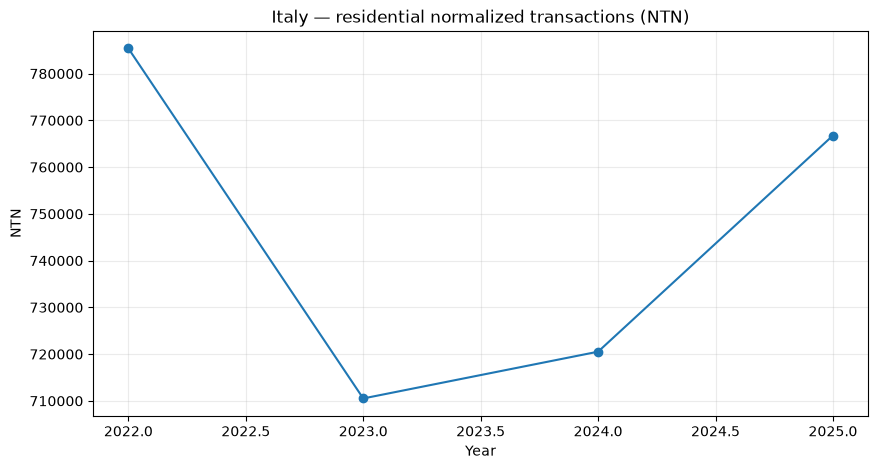

In [18]:
if not national_ntn.empty:
    plt.figure(figsize=(10,5))
    plt.plot(national_ntn.year, national_ntn.national_ntn, marker='o')
    plt.title('Italy — residential normalized transactions (NTN)')
    plt.xlabel('Year')
    plt.ylabel('NTN')
    plt.grid(alpha=0.25)
    plt.show()


## 7. Regional concentration

Regional rankings use total NTN by region. This avoids overweighting small municipalities.


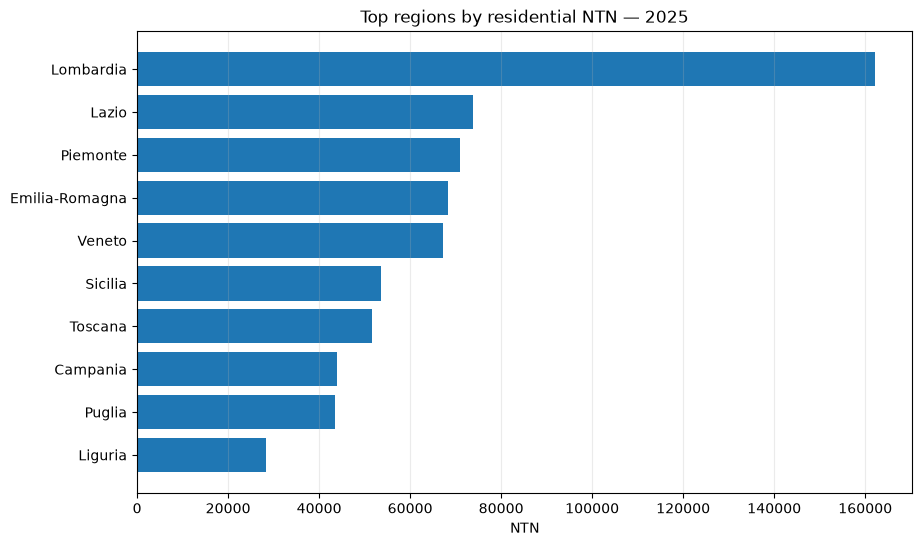

In [19]:
regional_ntn = (transactions_full.groupby(['year','Regione'], as_index=False)[total_ntn_col].sum(min_count=1).rename(columns={total_ntn_col:'ntn'})) if total_ntn_col else pd.DataFrame()
if not regional_ntn.empty:
    latest_year = regional_ntn.year.max()
    latest = regional_ntn[regional_ntn.year.eq(latest_year)].sort_values('ntn', ascending=False)
    latest.head(10)
    plt.figure(figsize=(10,6))
    top = latest.head(10).sort_values('ntn')
    plt.barh(top.Regione, top.ntn)
    plt.title(f'Top regions by residential NTN — {latest_year}')
    plt.xlabel('NTN')
    plt.grid(axis='x', alpha=0.25)
    plt.show()

## 8. Residential transaction mix by size

Shares show whether the structure of residential demand changes independently of overall market size.


In [21]:
if len(size_cols) == 5:
    labels = ['≤50 m²','50–85 m²','85–115 m²','115–145 m²','>145 m²']
    size_long = transactions_full.melt(id_vars=['year','CodCom','Regione','Comune'], value_vars=size_cols, var_name='size_band', value_name='ntn')
    mapping = dict(zip(size_cols, labels))
    size_long['size_band'] = size_long.size_band.map(mapping)
    size_mix = size_long.groupby(['year','size_band'], as_index=False).ntn.sum(min_count=1)
    size_mix['share_pct'] = size_mix.ntn / size_mix.groupby('year').ntn.transform('sum') * 100
    display(size_mix)
    pivot = size_mix.pivot(index='year', columns='size_band', values='share_pct')
    ax = pivot.plot(figsize=(10,6), marker='o')
    ax.set_title('Residential transaction mix by property size')
    ax.set_xlabel('Year')
    ax.set_ylabel('Share of NTN (%)')
    ax.grid(alpha=0.25)
    plt.show()

## 9. Municipality panel

The municipality-year panel is the main analytical hand-off: it can support rankings, segmentation and the future price–volume model.


In [22]:
municipality_panel = transactions_full[['year','CodCom','Comune','Regione','Provincia','TAGLIA MERCATO',total_ntn_col]].rename(columns={total_ntn_col:'ntn'}).copy()
municipality_panel = municipality_panel.sort_values(['CodCom','year'])
municipality_panel['ntn_yoy_pct'] = municipality_panel.groupby('CodCom').ntn.pct_change() * 100
latest_panel = municipality_panel[municipality_panel.year.eq(municipality_panel.year.max())].copy()
latest_panel.sort_values('ntn', ascending=False).head(15)

,year,CodCom,Comune,Regione,Provincia,TAGLIA MERCATO,ntn,ntn_yoy_pct
112213,2025,H501,ROMA,Lazio,RM,XXL,37292.95,6.164725
110499,2025,F205,MILANO,Lombardia,MI,XXL,25172.96,4.874661
113425,2025,L219,TORINO,Piemonte,TO,XL,16151.20,6.822296
109610,2025,D969,GENOVA,Liguria,GE,XL,9273.41,5.492104
110976,2025,F839,NAPOLI,Campania,NaN,XL,8030.87,3.029218
111311,2025,G273,PALERMO,Sicilia,PA,XL,7140.41,9.350291
107414,2025,A944,BOLOGNA,Emilia-Romagna,BO,XL,6089.18,5.202070
109336,2025,D612,FIRENZE,Toscana,FI,XL,4643.31,-3.759612
107213,2025,A662,BARI,Puglia,BA,XL,4243.15,-22.334851
108452,2025,C351,CATANIA,Sicilia,CT,XL,4227.03,9.417557


## 10. Data-quality dashboard and hand-off

The final checks make the notebook auditable and prevent silent structural errors.

### Controls
- annual release inventory is discovered automatically;
- `CodCom` duplicates are checked before joins;
- joins enforce one-to-one relationships;
- municipality-year uniqueness is asserted;
- residential size classes are reconciled with total NTN when the schema permits;
- missing values are preserved rather than imputed.

### Interpretation limits
NTN is a normalized transaction indicator, not a simple count of deeds or physical properties. Volume trends should not be interpreted as price trends. Geographic coverage and reference structures may also change over time.

### Next step
Link this validated municipality-year transaction panel to the quotation dataset from Notebook 01 using a controlled geographic/reference-period key. The target analytical dataset will contain **OMI price midpoint + residential NTN**, enabling a genuine price–volume market analysis.